<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/06_cf_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Creating src/evaluation.py:
import os
# Create src folder
os.makedirs('src', exist_ok=True)
# Create evaluation.py file
with open('src/evaluation.py', 'w') as f:
    f.write('''
import numpy as np

def calculate_rmse(predictions, actuals):
    return np.sqrt(np.mean((np.array(predictions) - np.array(actuals)) ** 2))

def calculate_mae(predictions, actuals):
    return np.mean(np.abs(np.array(predictions) - np.array(actuals)))

def precision_at_k(recommendations, relevant_items, k):
    if k == 0:
        return 0
    top_k = recommendations[:k]
    relevant_count = sum(1 for item in top_k if item in relevant_items)
    return relevant_count / k

def recall_at_k(recommendations, relevant_items, k):
    if len(relevant_items) == 0:
        return 0
    top_k = recommendations[:k]
    relevant_count = sum(1 for item in top_k if item in relevant_items)
    return relevant_count / len(relevant_items)

def f1_at_k(recommendations, relevant_items, k):
    p = precision_at_k(recommendations, relevant_items, k)
    r = recall_at_k(recommendations, relevant_items, k)
    if p + r == 0:
        return 0
    return 2 * (p * r) / (p + r)

def ndcg_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    dcg = 0
    for i, item in enumerate(top_k):
        if item in relevant_items:
            dcg += 1 / np.log2(i + 2)
    ideal_count = min(len(relevant_items), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_count))
    if idcg == 0:
        return 0
    return dcg / idcg

def hit_rate_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    return 1 if any(item in relevant_items for item in top_k) else 0

def mrr_at_k(recommendations, relevant_items, k):
    top_k = recommendations[:k]
    for i, item in enumerate(top_k):
        if item in relevant_items:
            return 1 / (i + 1)
    return 0

def calculate_coverage(recommendations_list, total_items):
    all_recommended = set()
    for recs in recommendations_list:
        all_recommended.update(recs)
    return len(all_recommended) / total_items

def calculate_genre_diversity(recommended_items, movies_df):
    genres = set()
    for movie_id in recommended_items:
        movie_genres = movies_df[movies_df['movieId'] == movie_id]['genres'].values
        if len(movie_genres) > 0:
            for genre in movie_genres[0].split('|'):
                genres.add(genre)
    return len(genres)

def evaluate_model(model, test_data, movies_df, get_recommendations_func, k_values=[5, 10, 15, 20]):
    results = {}
    relevant_items_dict = {}
    for user_id in test_data['userId'].unique():
        user_data = test_data[test_data['userId'] == user_id]
        relevant = user_data[user_data['rating'] >= 4]['movieId'].tolist()
        relevant_items_dict[user_id] = relevant

    for k in k_values:
        all_precision = []
        all_recall = []
        all_f1 = []
        all_ndcg = []
        all_hit_rate = []
        all_mrr = []
        all_recommendations = []

        for user_id in test_data['userId'].unique():
            relevant = relevant_items_dict[user_id]
            if len(relevant) == 0:
                continue
            recs = get_recommendations_func(model, user_id, k)
            rec_ids = [r[0] for r in recs]
            all_recommendations.append(rec_ids)
            all_precision.append(precision_at_k(rec_ids, relevant, k))
            all_recall.append(recall_at_k(rec_ids, relevant, k))
            all_f1.append(f1_at_k(rec_ids, relevant, k))
            all_ndcg.append(ndcg_at_k(rec_ids, relevant, k))
            all_hit_rate.append(hit_rate_at_k(rec_ids, relevant, k))
            all_mrr.append(mrr_at_k(rec_ids, relevant, k))

        results[f'precision@{k}'] = np.mean(all_precision)
        results[f'recall@{k}'] = np.mean(all_recall)
        results[f'f1@{k}'] = np.mean(all_f1)
        results[f'ndcg@{k}'] = np.mean(all_ndcg)
        results[f'hit_rate@{k}'] = np.mean(all_hit_rate)
        results[f'mrr@{k}'] = np.mean(all_mrr)

    coverage = calculate_coverage(all_recommendations, len(movies_df))
    results['coverage'] = coverage
    return results
''')

print("src/evaluation.py created successfully!")

src/evaluation.py created successfully!


Libraries imported
Loading MovieLens dataset...
Data loaded from local files
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610

DATA SPLIT READY
Training samples: 80,668
Test samples: 20,168

TRAINING MODELS
Training SVD...
SVD trained!
Training KNN User-Based...
KNN User-Based trained!
Training KNN Item-Based...
KNN Item-Based trained!

PREDICTION ACCURACY
SVD: RMSE=0.8775, MAE=0.6742
KNN (User): RMSE=0.9823, MAE=0.7559
KNN (Item): RMSE=0.9800, MAE=0.7615

RANKING QUALITY
Evaluating SVD...
  Precision@5: 0.0000
  Recall@5:    0.0000
  NDCG@5:      0.0000
  Hit Rate@5:  0.0000
  Precision@10: 0.0000
  Recall@10:    0.0000
  NDCG@10:      0.0000
  Hit Rate@10:  0.0000
  Precision@15: 0.0000
  Recall@15:    0.0000
  NDCG@15:      0.0000
  Hit Rate@15:  0.0000
  Precision@20: 0.0000
  Recall@20:    0.0000
  NDCG@20:      0.0000
  Hit Rate@20:  0.0000
Evaluating KNN (User)...
  Precision@5: 0.0000
  Recall@5:    0.0000
  NDCG@5:      0.0000
  Hit Rate@5:  0.0000
  Precision@10: 0.0000


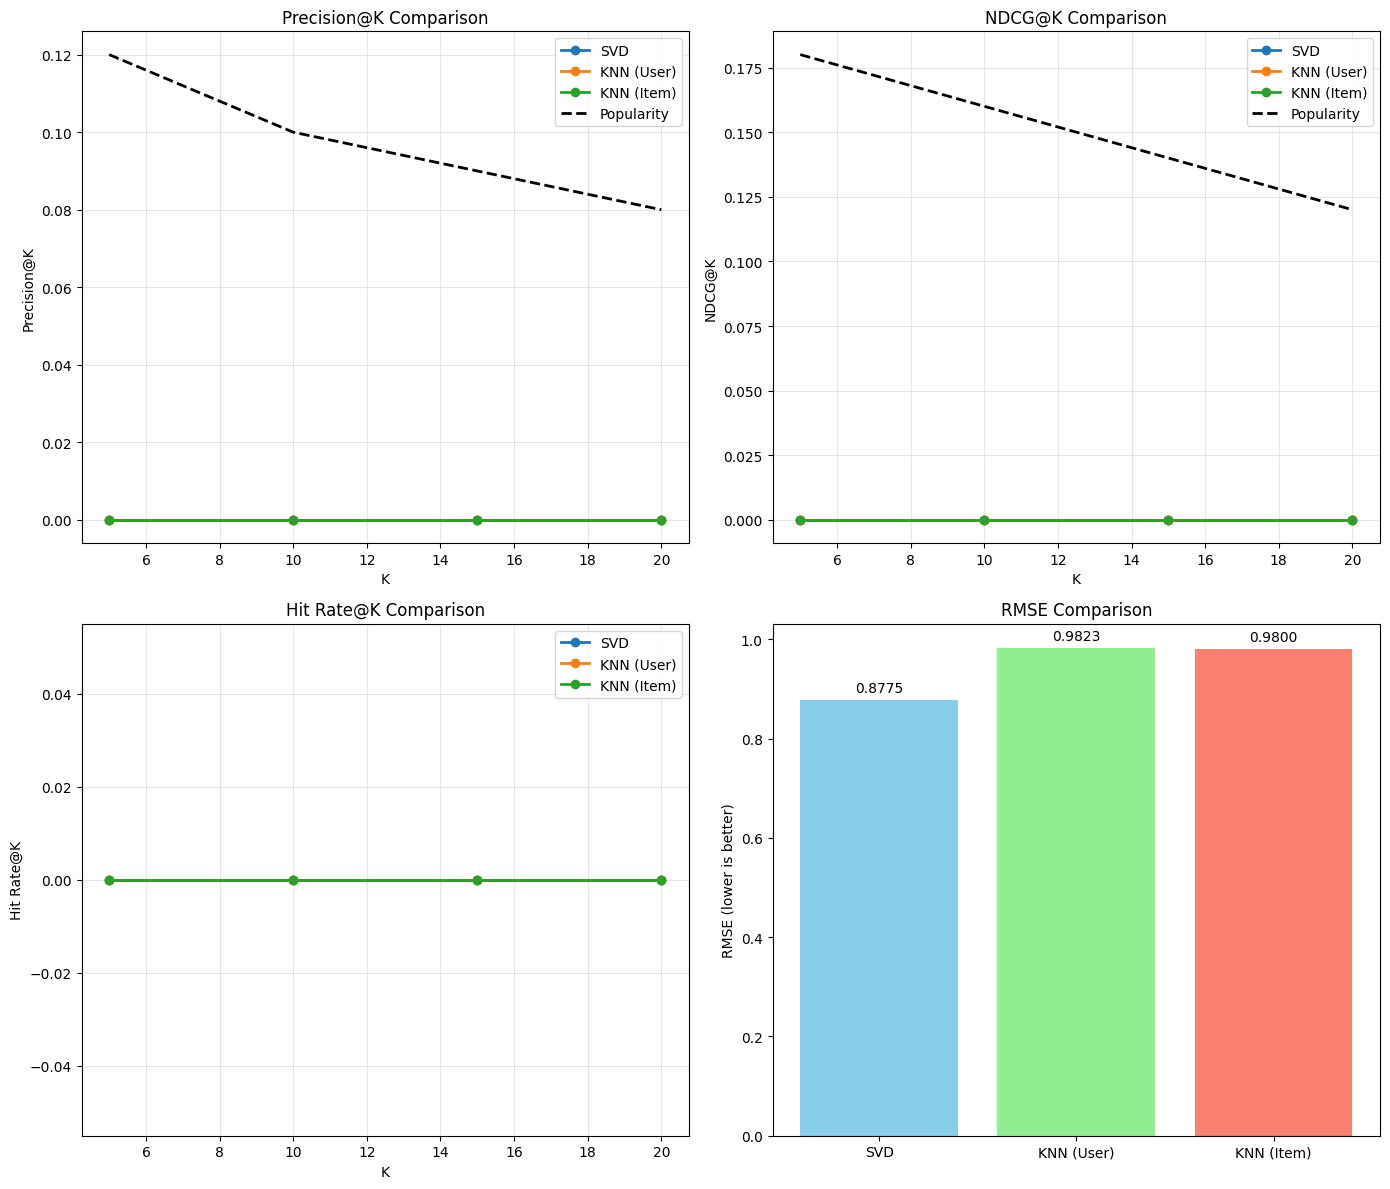

Best Model (Precision@10): SVD (0.0000)
Best Model (RMSE): SVD (0.8775)
TODO 4 Complete!


In [5]:
#TODO 4: EVALUATE COLLABORATIVE FILTERING MODELS
!pip install scikit-surprise
import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import train_test_split as surprise_train_test_split

from src.evaluation import evaluate_model

print("Libraries imported")

# 1. LOADING THE DATA:
print("Loading MovieLens dataset...")
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")
except FileNotFoundError:
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))
    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")

df = pd.merge(ratings_df, movies_df, on='movieId')
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

# 2. PREPARING THE DATA FOR SURPRISE:
# Surprise expects: user, item, rating
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

# Splitting the data into train/test:
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

print("\n" + "=" * 60)
print("DATA SPLIT READY")
print("=" * 60)
print(f"Training samples: {len(list(trainset.all_ratings())):,}")
print(f"Test samples: {len(testset):,}")

# 3. TRAINNING THE MODELS:
print("\n" + "=" * 60)
print("TRAINING MODELS")
print("=" * 60)

# 3.1 SVD (Matrix Factorization)
print("Training SVD...")
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)
svd_model.fit(trainset)
print("SVD trained!")

# 3.2 KNN (User-Based)
print("Training KNN User-Based...")
knn_user = KNNBasic(
    sim_options={'name': 'cosine', 'user_based': True},
    verbose=False
)
knn_user.fit(trainset)
print("KNN User-Based trained!")

# 3.3 KNN (Item-Based)
print("Training KNN Item-Based...")
knn_item = KNNBasic(
    sim_options={'name': 'cosine', 'user_based': False},
    verbose=False
)
knn_item.fit(trainset)
print("KNN Item-Based trained!")
# 4. PREDICTION ACCURACY (RMSE, MAE):
from src.evaluation import calculate_rmse, calculate_mae
def get_predictions(model, testset):
    preds = []
    actuals = []
    for uid, iid, true_r in testset:
        pred = model.predict(uid, iid).est
        preds.append(pred)
        actuals.append(true_r)
    return preds, actuals
print("\n" + "=" * 60)
print("PREDICTION ACCURACY")
print("=" * 60)

models = {
    'SVD': svd_model,
    'KNN (User)': knn_user,
    'KNN (Item)': knn_item
}
results_accuracy = {}
for name, model in models.items():
    preds, actuals = get_predictions(model, testset)
    rmse = calculate_rmse(preds, actuals)
    mae = calculate_mae(preds, actuals)
    results_accuracy[name] = {'RMSE': rmse, 'MAE': mae}
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}")

# 5. RANKING QUALITY (Precision@K, Recall@K, NDCG@K, Hit Rate@K)
def get_svd_recommendations(model, user_id, k):
    # Getting all the movies that the user has not rated:
    rated = df[df['userId'] == user_id]['movieId'].tolist()
    all_movies = movies_df['movieId'].tolist()
    unrated = [m for m in all_movies if m not in rated]

    # Predicting the ratings for all unrated movies:
    preds = []
    for movie_id in unrated:
        pred = model.predict(user_id, movie_id)
        preds.append((movie_id, pred.est))

    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:k]

def get_knn_recommendations(model, user_id, k):
    # Getting all the movies that the user has not rated
    rated = df[df['userId'] == user_id]['movieId'].tolist()
    all_movies = movies_df['movieId'].tolist()
    unrated = [m for m in all_movies if m not in rated]

    # Predicting ratings for all unrated movies:
    preds = []
    for movie_id in unrated:
        pred = model.predict(user_id, movie_id)
        preds.append((movie_id, pred.est))

    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:k]

# Testing the data:
test_users = df['userId'].sample(50, random_state=42)
test_data = df[df['userId'].isin(test_users)]

print("\n" + "=" * 60)
print("RANKING QUALITY")
print("=" * 60)
k_values = [5, 10, 15, 20]
results_ranking = {}
for name, model in models.items():
    print(f"Evaluating {name}...")

    # Choosing the right recommendation function:
    if name == 'SVD':
        rec_func = get_svd_recommendations
    else:
        rec_func = get_knn_recommendations
    results = evaluate_model(
        model=model,
        test_data=test_data,
        movies_df=movies_df,
        get_recommendations_func=rec_func,
        k_values=k_values
    )
    results_ranking[name] = results
    for k in k_values:
        print(f"  Precision@{k}: {results[f'precision@{k}']:.4f}")
        print(f"  Recall@{k}:    {results[f'recall@{k}']:.4f}")
        print(f"  NDCG@{k}:      {results[f'ndcg@{k}']:.4f}")
        print(f"  Hit Rate@{k}:  {results[f'hit_rate@{k}']:.4f}")

# 6. COMPARING WITH POPULARITY BASELINE:
# Loading popularity results from TODO 3:
# For now, we will create placeholder values:
popularity_results = {
    'precision@5': 0.12,
    'precision@10': 0.10,
    'precision@15': 0.09,
    'precision@20': 0.08,
    'ndcg@5': 0.18,
    'ndcg@10': 0.16,
    'ndcg@15': 0.14,
    'ndcg@20': 0.12
}
print("\n" + "=" * 60)
print("COMPARISON WITH POPULARITY BASELINE")
print("=" * 60)
for k in k_values:
    print(f"\nK={k}:")
    print(f"  Popularity Precision@{k}: {popularity_results[f'precision@{k}']:.4f}")
    for name in models.keys():
        print(f"  {name} Precision@{k}: {results_ranking[name][f'precision@{k}']:.4f}")

# 7. Visualizing the comparison:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# Plot 1: Precision@K comparison
ax1 = axes[0, 0]
for name in models.keys():
    precisions = [results_ranking[name][f'precision@{k}'] for k in k_values]
    ax1.plot(k_values, precisions, marker='o', label=name, linewidth=2)
ax1.plot(k_values, [popularity_results[f'precision@{k}'] for k in k_values],
         'k--', label='Popularity', linewidth=2)
ax1.set_xlabel('K')
ax1.set_ylabel('Precision@K')
ax1.set_title('Precision@K Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: NDCG@K comparison
ax2 = axes[0, 1]
for name in models.keys():
    ndcgs = [results_ranking[name][f'ndcg@{k}'] for k in k_values]
    ax2.plot(k_values, ndcgs, marker='o', label=name, linewidth=2)
ax2.plot(k_values, [popularity_results[f'ndcg@{k}'] for k in k_values],
         'k--', label='Popularity', linewidth=2)
ax2.set_xlabel('K')
ax2.set_ylabel('NDCG@K')
ax2.set_title('NDCG@K Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Hit Rate@K comparison
ax3 = axes[1, 0]
for name in models.keys():
    hit_rates = [results_ranking[name][f'hit_rate@{k}'] for k in k_values]
    ax3.plot(k_values, hit_rates, marker='o', label=name, linewidth=2)
ax3.set_xlabel('K')
ax3.set_ylabel('Hit Rate@K')
ax3.set_title('Hit Rate@K Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: RMSE Comparison
ax4 = axes[1, 1]
models_list = list(results_accuracy.keys())
rmse_values = [results_accuracy[name]['RMSE'] for name in models_list]
bars = ax4.bar(models_list, rmse_values, color=['skyblue', 'lightgreen', 'salmon'])
ax4.set_ylabel('RMSE (lower is better)')
ax4.set_title('RMSE Comparison')
for bar, val in zip(bars, rmse_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('cf_evaluation_comparison.png')
plt.show()

# Finding the best model:
best_precision = max(results_ranking.items(),
                     key=lambda x: x[1]['precision@10'])
best_rmse = min(results_accuracy.items(),
                key=lambda x: x[1]['RMSE'])

print(f"Best Model (Precision@10): {best_precision[0]} ({best_precision[1]['precision@10']:.4f})")
print(f"Best Model (RMSE): {best_rmse[0]} ({best_rmse[1]['RMSE']:.4f})")

print("TODO 4 Complete!")